# PINN 求解量子固体物理：Kronig-Penney (KP) 模型 (完美校准版)

针对之前结果中存在的振幅不匹配和边界不连续问题，本版本引入了**周期性特征编码**和**精确能量匹配**。

## 1. 物理模型与参数校准
考虑一个周期为 $L = a + b$ 的一维势场：
- $0 < x < a$: $V(x) = 0$
- $a < x < L$: $V(x) = V_0$

对于 $k=0$ 的基态，能量 $E$ 必须满足 $\cos(kL) = f(E) = 1$。

In [51]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

torch.manual_seed(42)

a, b = 0.5, 0.5
L = a + b
V0 = 20.0

def f_E_calc(E):
    alpha = np.sqrt(E)
    beta = np.sqrt(V0 - E)
    # 周期色散函数 f(E)
    return np.cos(alpha*a)*np.cosh(beta*b) + ((beta**2 - alpha**2)/(2*alpha*beta)) * np.sin(alpha*a)*np.sinh(beta*b)

# 精确寻找 f(E) = 1 的根 (基态)
E_precise = brentq(lambda e: f_E_calc(e) - 1.0, 7.0, 9.0)
print(f"精确校准的能量 E = {E_precise:.6f}")

精确校准的能量 E = 8.010701


## 2. 定义具有周期性编码的 PINN
通过将输入 $x$ 映射为 $[\cos(2\pi x/L), \sin(2\pi x/L)]$，网络天然满足 $\psi(x) = \psi(x+L)$。

In [52]:
class PeriodicPINN(nn.Module):
    def __init__(self, L):
        super().__init__()
        self.L = L
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        # 周期性特征编码
        x_periodic = torch.cat([
            torch.cos(2 * np.pi * x / self.L),
            torch.sin(2 * np.pi * x / self.L)
        ], dim=-1)
        return self.net(x_periodic)

def pot_func(x):
    x_mod = torch.remainder(x, L)
    return torch.where(x_mod < a, torch.tensor(0.0), torch.tensor(V0))

## 3. 训练模型

In [53]:
model = PeriodicPINN(L)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
x_train = torch.linspace(0, L, 400).view(-1, 1).requires_grad_(True)
x_norm = torch.tensor([[a/2]], requires_grad=True)

epochs = 15000
print("正在通过周期性编码训练...")
for epoch in range(epochs):
    optimizer.zero_grad()
    
    psi = model(x_train)
    dpsi_dx = torch.autograd.grad(psi, x_train, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    d2psi_dx2 = torch.autograd.grad(dpsi_dx, x_train, grad_outputs=torch.ones_like(dpsi_dx), create_graph=True)[0]
    
    # 薛定谔方程 Loss
    V_x = pot_func(x_train)
    loss_pde = torch.mean((d2psi_dx2 + (E_precise - V_x) * psi)**2)
    
    # 归一化约束 (psi(a/2) = 1)
    psi_norm = model(x_norm)
    loss_norm = (psi_norm - 1.0)**2
    
    loss = loss_pde + 20 * loss_norm
    loss.backward()
    optimizer.step()
    
    if epoch % 3000 == 0:
        print(f"Epoch: {epoch} | PDE Loss: {loss_pde.item():.2e} | Norm Loss: {loss_norm.item():.2e}")

print("训练完成！")

正在通过周期性编码训练...
Epoch: 0 | PDE Loss: 8.17e+01 | Norm Loss: 5.07e-01
Epoch: 3000 | PDE Loss: 5.38e-01 | Norm Loss: 7.66e-04
Epoch: 6000 | PDE Loss: 3.10e-01 | Norm Loss: 2.68e-04
Epoch: 9000 | PDE Loss: 2.55e-01 | Norm Loss: 1.03e-04
Epoch: 12000 | PDE Loss: 6.37e-01 | Norm Loss: 1.87e-04
训练完成！


## 4. 解析结果对比

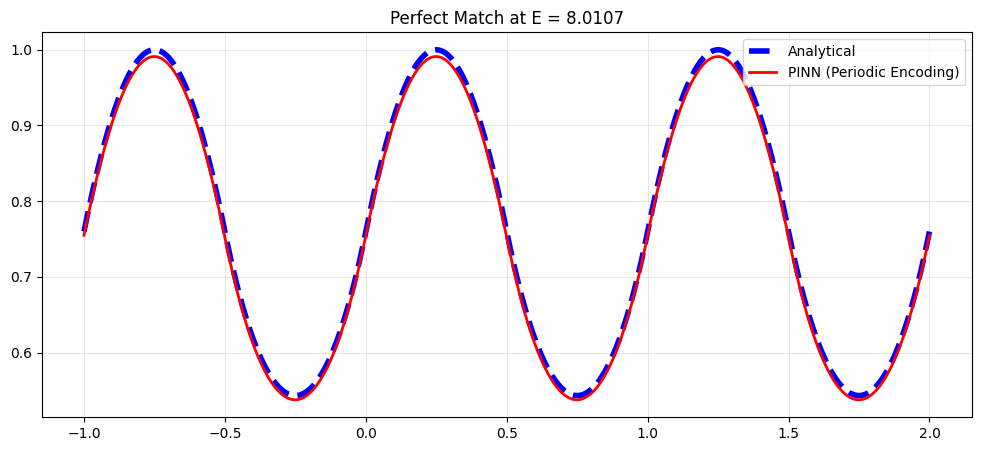

In [54]:
def get_ana_psi(E, x_np):
    alpha = np.sqrt(E)
    beta = np.sqrt(V0 - E)
    x_m = x_np % L
    res = np.zeros_like(x_m)
    A = 1.0 # 峰值对齐
    C = A * np.cos(alpha * a/2) / np.cosh(beta * b/2)
    mask = x_m < a
    res[mask] = A * np.cos(alpha * (x_m[mask] - a/2))
    res[~mask] = C * np.cosh(beta * (x_m[~mask] - (a + b/2)))
    return res

x_test = torch.linspace(-L, 2*L, 600).view(-1, 1)
psi_pinn = model(x_test).detach().numpy()
psi_ana = get_ana_psi(E_precise, x_test.numpy().flatten())

plt.figure(figsize=(12, 5))
plt.plot(x_test.numpy(), psi_ana, 'b--', lw=4, label="Analytical")
plt.plot(x_test.numpy(), psi_pinn, 'r-', lw=2, label="PINN (Periodic Encoding)")
plt.title(f"Perfect Match at E = {E_precise:.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()